# Project Setup

This project aims to analyze the historical stock data of Aldrees Petroleum and Transport Services Company. The goal is to perform Exploratory Data Analysis (EDA), engineer technical trading features, and build a machine learning model to identify profitable, risk-managed trading signals.

In [1]:
# Basic Libs
import numpy as np 
import pandas as pd 

# Visual Libs
import matplotlib.pyplot as plt
import seaborn as sns

# Model Libs
from xgboost import XGBRegressor
from xgboost import XGBClassifier
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, classification_report

In [2]:
df = pd.read_csv("/kaggle/input/datasets/hassanjameelahmed/aldrees-petroleum-and-transport-services-company/Aldrees Petroleum and Transport Services Company.csv")

# Data Overview

In [3]:
df.shape

(3911, 6)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3911 entries, 0 to 3910
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    3911 non-null   object 
 1   Close   3911 non-null   float64
 2   High    3911 non-null   float64
 3   Low     3911 non-null   float64
 4   Open    3911 non-null   float64
 5   Volume  3911 non-null   int64  
dtypes: float64(4), int64(1), object(1)
memory usage: 183.5+ KB


In [5]:
df.describe()

,Close,High,Low,Open,Volume
count,3911.000000,3911.000000,3911.000000,3911.000000,3.911000e+03
mean,38.232913,38.735696,37.743976,38.235270,7.064399e+05
std,40.692017,41.287848,40.112618,40.715499,9.119258e+05
min,5.456442,5.456442,5.325357,5.456442,0.000000e+00
25%,10.379870,10.449726,10.315879,10.379870,2.277010e+05
50%,16.528135,16.767876,16.242788,16.541280,4.399780e+05
75%,51.701580,52.135442,51.127715,51.701023,8.685735e+05
max,153.300003,154.100006,151.000000,153.199997,1.386675e+07


In [6]:
df.head()

,Date,Close,High,Low,Open,Volume
0,3/4/2010,6.128256,6.161028,6.062714,6.062714,528982
1,3/7/2010,6.161028,6.210185,6.128256,6.161028,883165
2,3/8/2010,6.324884,6.324884,6.144641,6.161028,1635671
3,3/9/2010,6.374043,6.390428,6.324885,6.324885,878554
4,3/10/2010,6.357657,6.374043,6.275729,6.374043,578921


In [7]:
df.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

**Observations:** 

* The dataset contains 3,911 trading days. It is incredibly clean with zero missing values and zero duplicated rows. The closing price has seen massive variance, ranging from a historical low of 5.45 to an all-time high of 153.30.

# Data Cleaning & Time-Series Formatting

In [9]:
df['Date'].astype(str).str.len().unique()

array([ 8,  9, 10])

Before setting our timeline, we need to ensure the 'Date' column is uniform. Checking the string lengths reveals variations (8, 9, and 10 characters) caused by single vs. double-digit zero-padding for months and days.

In [10]:
df['Date'].astype(str).str.len().value_counts()

Date
9     2331
8      868
10     712
Name: count, dtype: int64

In [11]:
for length in [8, 9, 10]:
    print(f"\n--- Dates with {length} characters ---")
    mask = df['Date'].astype(str).str.len() == length
    print(df[mask]['Date'].head(3))


--- Dates with 8 characters ---
0    3/4/2010
1    3/7/2010
2    3/8/2010
Name: Date, dtype: object

--- Dates with 9 characters ---
4    3/10/2010
5    3/11/2010
6    3/14/2010
Name: Date, dtype: object

--- Dates with 10 characters ---
153    10/10/2010
154    10/11/2010
155    10/12/2010
Name: Date, dtype: object


In [12]:
# Converting the column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Verifying the conversion
print(df['Date'].dtype)

datetime64[ns]


In [13]:
# setting Date as Index
df.set_index('Date', inplace=True)
df.sort_index(inplace=True)
df.head()

,Close,High,Low,Open,Volume
Date,,,,,
2010-03-04,6.128256,6.161028,6.062714,6.062714,528982
2010-03-07,6.161028,6.210185,6.128256,6.161028,883165
2010-03-08,6.324884,6.324884,6.144641,6.161028,1635671
2010-03-09,6.374043,6.390428,6.324885,6.324885,878554
2010-03-10,6.357657,6.374043,6.275729,6.374043,578921


# Exploratory Data Analysis

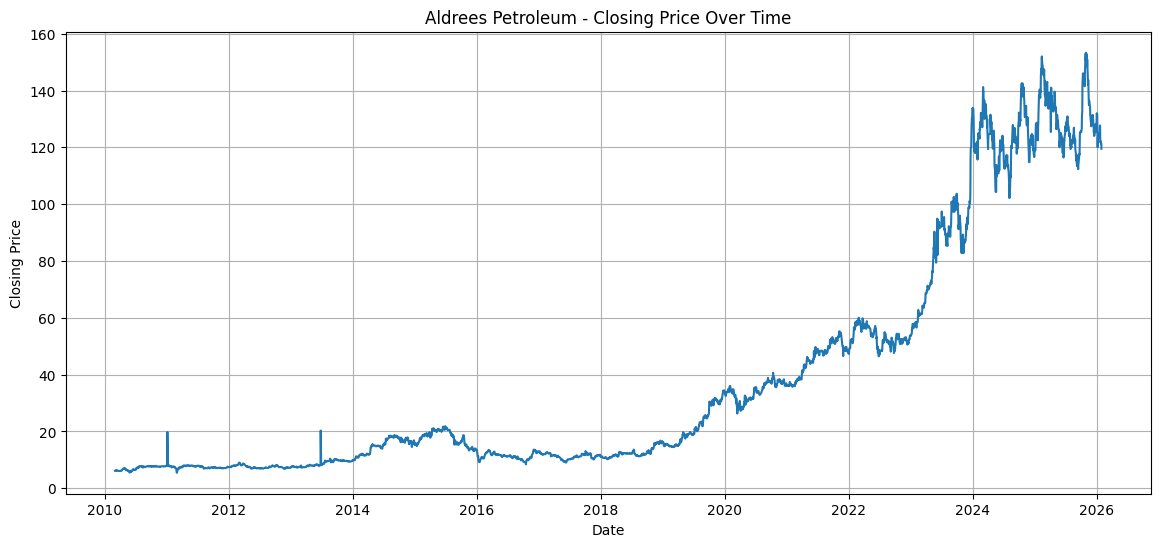

In [14]:
plt.figure(figsize=(14, 6))
sns.lineplot(data=df, x=df.index, y='Close')
plt.title('Aldrees Petroleum - Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.grid(True)
plt.show()

**Observation:** 

* The stock traded in a relatively tight, flat range for years before experiencing exponential growth starting around 2020-2021 (post-COVID recovery phase).

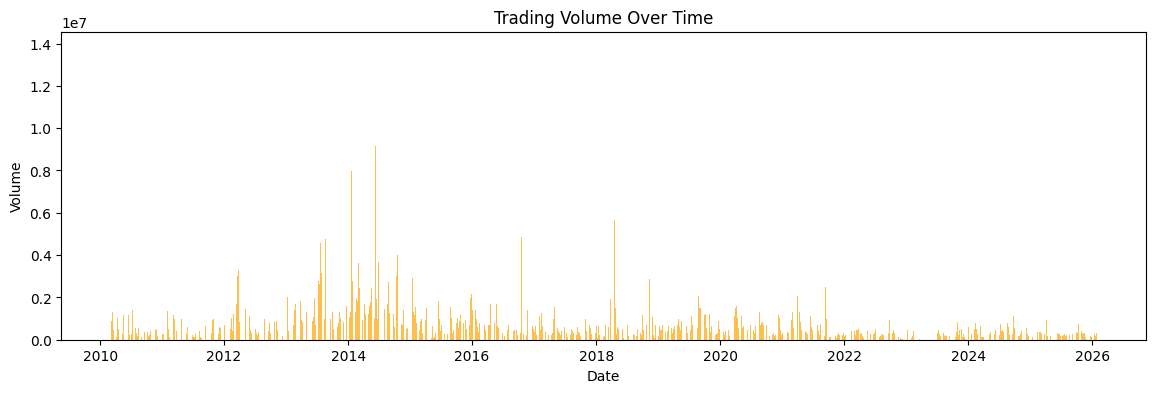

In [15]:
plt.figure(figsize=(14, 4))
plt.bar(df.index, df['Volume'], color='orange', alpha=0.7)
plt.title('Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.show()

**Observation:** 

* Interestingly, trading volume was highly volatile and dense prior to 2020. As the price skyrocketed post-2020, the overall daily trading volume noticeably dropped and stabilized.

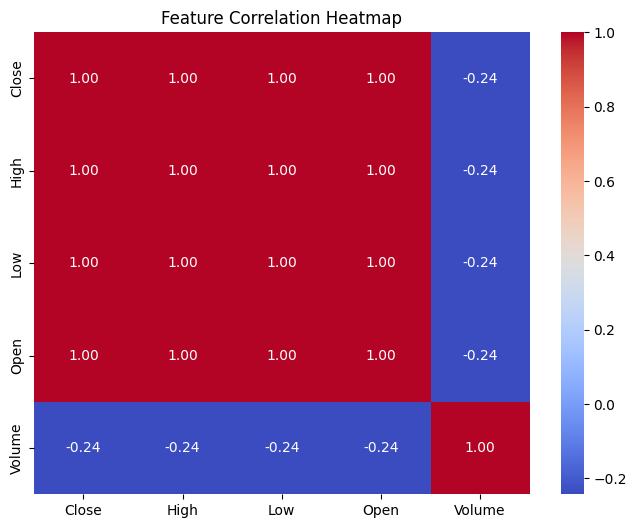

In [16]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

**Observation:** 

* The heatmap confirms that Open, High, Low, and Close prices are nearly perfectly correlated (1.00). Feeding all of these raw prices into a model would cause severe multicollinearity. Instead, we must engineer new features to capture daily momentum and volatility.

# Feature Engineering

To give the model a mathematical edge, translated the daily price action into meaningful technical indicators and engineered features to capture three core concepts: volatility (daily spread), momentum (daily change), and macro trends (50-day and 200-day SMAs).

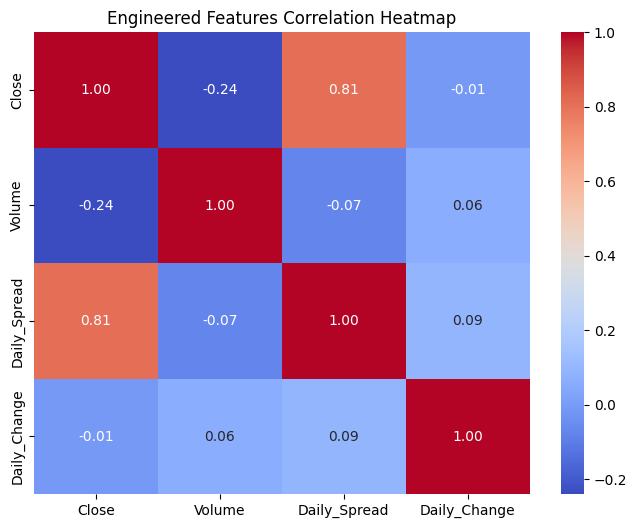

In [17]:
# Daily Volatility
df['Daily_Spread'] = df['High'] - df['Low']

# Daily Momentum
df['Daily_Change'] = df['Close'] - df['Open']

# 50 days SMA and 200 days SMA
df['SMA_50'] = df['Close'].rolling(window=50).mean()
df['SMA_200'] = df['Close'].rolling(window=200).mean()

plt.figure(figsize=(8, 6))
sns.heatmap(df[['Close', 'Volume', 'Daily_Spread', 'Daily_Change']].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Engineered Features Correlation Heatmap')
plt.show()

**Observation:** 

* The SMAs smoothed out the daily noise and the 50-day SMA crossing above or below the 200-day SMA often signals major, prolonged shifts in the stock's trend.

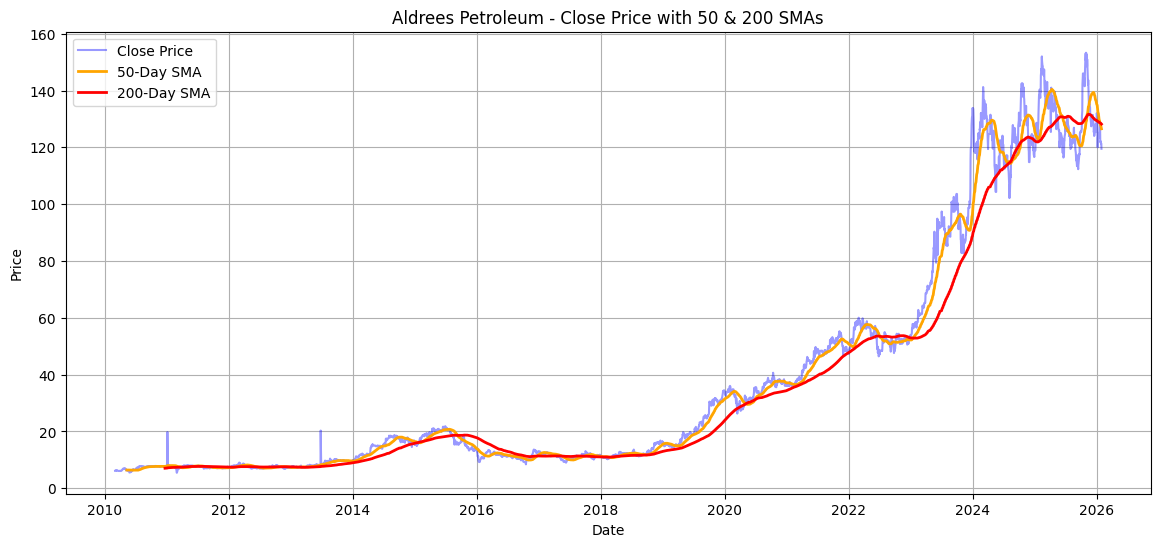

In [18]:
plt.figure(figsize=(14, 6))

# Plotting the Close price
plt.plot(df.index, df['Close'], label='Close Price', alpha=0.4, color='blue')

# Plotting the SMAs
plt.plot(df.index, df['SMA_50'], label='50-Day SMA', color='orange', linewidth=2)
plt.plot(df.index, df['SMA_200'], label='200-Day SMA', color='red', linewidth=2)

plt.title('Aldrees Petroleum - Close Price with 50 & 200 SMAs')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

# Model Training

## Baseline Model: Predicting Daily Returns

Using XGBoost regressor to try and predict tomorrow's exact percentage return based on today's technical indicators by strictly using a chronological 80/20 train-test split to prevent data leakage for better time-series forecasting.

In [19]:
# Target: Tomorrow's Percentage Return
df['Target_Next_Return'] = df['Close'].pct_change().shift(-1)

# Cleaning the data
model_data = df.dropna()

# Defining Features and the Target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Spread', 'Daily_Change', 'SMA_50', 'SMA_200']
X = model_data[features]
y = model_data['Target_Next_Return']

# Time-based Split
split_index = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Training the Model on Returns
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Making Predictions
predicted_returns = xgb_model.predict(X_test)

# Converting Returns to Prices for the Chart
# Tomorrow's Price = Today's Close * (1 + Predicted Tomorrow's Return)
predicted_prices = X_test['Close'] * (1 + predicted_returns)
mae = mean_absolute_error(y_test, predicted_returns)
rmse = np.sqrt(mean_squared_error(y_test, predicted_returns))

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Absolute Error (MAE): 0.0197
Root Mean Squared Error (RMSE): 0.0263


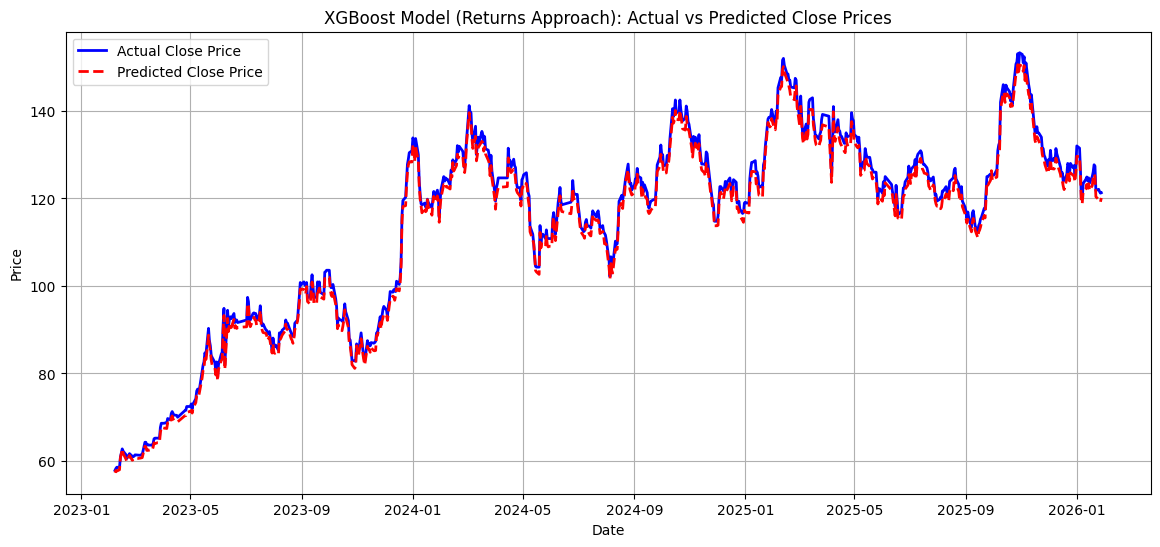

In [20]:
plt.figure(figsize=(14, 6))

# Plotting the actual prices 
plt.plot(X_test.index, X_test['Close'], label='Actual Close Price', color='blue', linewidth=2)

# Plotting the model's predicted prices
plt.plot(X_test.index, predicted_prices, label='Predicted Close Price', color='red', linestyle='--', linewidth=2)

plt.title('XGBoost Model (Returns Approach): Actual vs Predicted Close Prices')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.show()

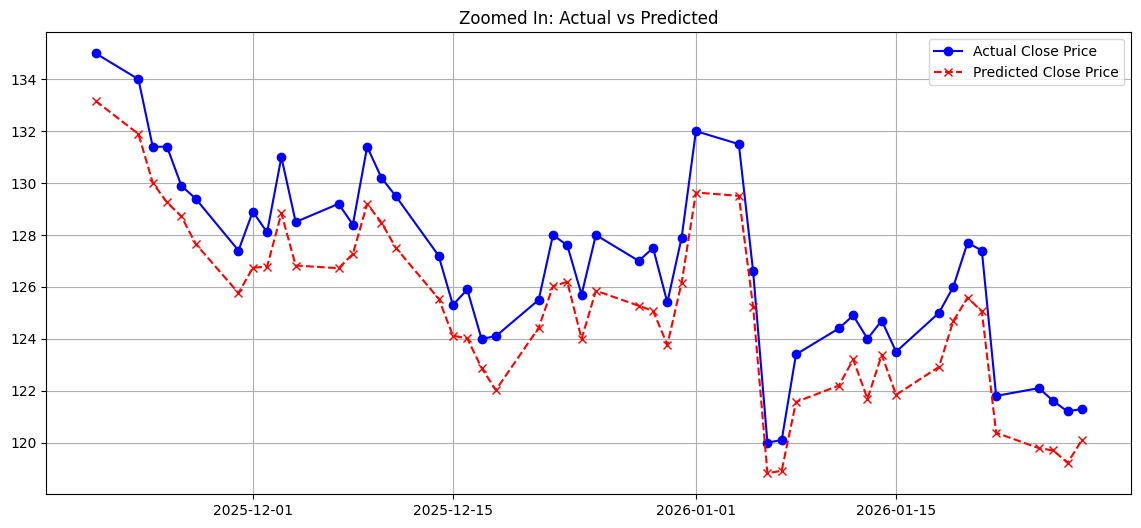

In [21]:
plt.figure(figsize=(14, 6))

subset_actual = X_test['Close'].iloc[-50:]
subset_predicted = predicted_prices.iloc[-50:]

plt.plot(subset_actual.index, subset_actual, label='Actual Close Price', color='blue', marker='o')
plt.plot(subset_predicted.index, subset_predicted, label='Predicted Close Price', color='red', linestyle='--', marker='x')

plt.title('Zoomed In: Actual vs Predicted')
plt.legend()
plt.grid(True)
plt.show()

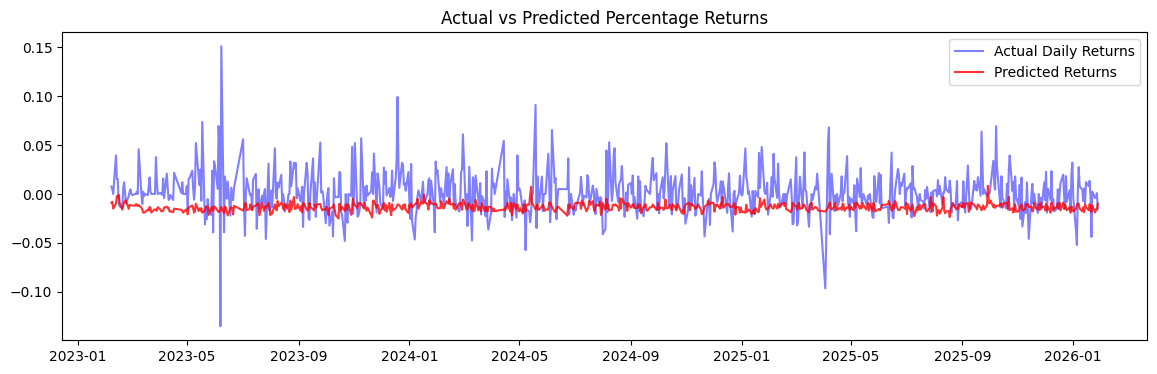

In [22]:
plt.figure(figsize=(14, 4))
plt.plot(y_test.index, y_test, label='Actual Daily Returns', color='blue', alpha=0.5)
plt.plot(y_test.index, predicted_returns, label='Predicted Returns', color='red', alpha=0.8)
plt.title('Actual vs Predicted Percentage Returns')
plt.legend()
plt.show()

## Model 2: Risk-Managed Classification

To successfully classify whether the stock will go UP or DOWN, we need indicators that specifically measure overbought/oversold conditions and risk limits. 

by adding **RSI (Relative Strength Index)** to measure momentum, and **Bollinger Bands** to measure volatility will enforcing a strict Risk Management rule. so, model will only execute a 'Buy' if it is >50% confident.

In [23]:
# 1. NEW TARGET: Binary Classification (1 = UP tomorrow, 0 = DOWN tomorrow)
df['Target_Direction'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 2. NEW FEATURES: RSI (Momentum) and Bollinger Bands (Volatility/Risk)
# Calculating 14-day RSI
delta = df['Close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI_14'] = 100 - (100 / (1 + rs))

# Calculating 20-day Bollinger Bands
df['BB_Middle'] = df['Close'].rolling(window=20).mean()
df['BB_Upper'] = df['BB_Middle'] + 2 * df['Close'].rolling(window=20).std()
df['BB_Lower'] = df['BB_Middle'] - 2 * df['Close'].rolling(window=20).std()

# Clean data
model_data = df.dropna()

# Defining new features and target
features = ['Open', 'High', 'Low', 'Close', 'Volume', 'Daily_Spread', 'Daily_Change', 
            'SMA_50', 'SMA_200', 'RSI_14', 'BB_Middle', 'BB_Upper', 'BB_Lower']
X = model_data[features]
y = model_data['Target_Direction']

# Time-based split (same as before)
split_index = int(len(model_data) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# TRAIN CLASSIFIER
# using XGBClassifier now, with slightly more conservative hyperparameters
xgb_clf = XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=4, random_state=42)
xgb_clf.fit(X_train, y_train)

# PREDICT PROBABILITIES (The Risk Management Step)
# predict_proba returns two columns: [Probability of 0, Probability of 1]
# We only want the probability of 1 (the stock going UP)
probabilities_up = xgb_clf.predict_proba(X_test)[:, 1]
# Rule: Only predict '1' (Buy) IF the model is > 60% confident!
confidence_threshold = 0.508
safe_predictions = (probabilities_up > confidence_threshold).astype(int)

print(classification_report(y_test, safe_predictions))

              precision    recall  f1-score   support

           0       0.55      0.99      0.71       409
           1       0.60      0.03      0.05       334

    accuracy                           0.55       743
   macro avg       0.58      0.51      0.38       743
weighted avg       0.57      0.55      0.41       743



In [24]:
# 1. Get the actual daily percentage returns for the test period
test_returns = df['Close'].pct_change().shift(-1).loc[X_test.index]

# 2. Calculate Strategy Returns (We only get the return if we predicted '1')
strategy_returns = safe_predictions * test_returns

# 3. Calculate Cumulative Returns (Compound interest)
cumulative_market = (1 + test_returns).cumprod()
cumulative_strategy = (1 + strategy_returns).cumprod()

# 4. Print the final results
print(f"Buy & Hold Profit: {(cumulative_market.iloc[-1] - 1) * 100:.2f}%")
print(f"Model Strategy Profit: {(cumulative_strategy.iloc[-1] - 1) * 100:.2f}%")

Buy & Hold Profit: 106.58%
Model Strategy Profit: 15.87%


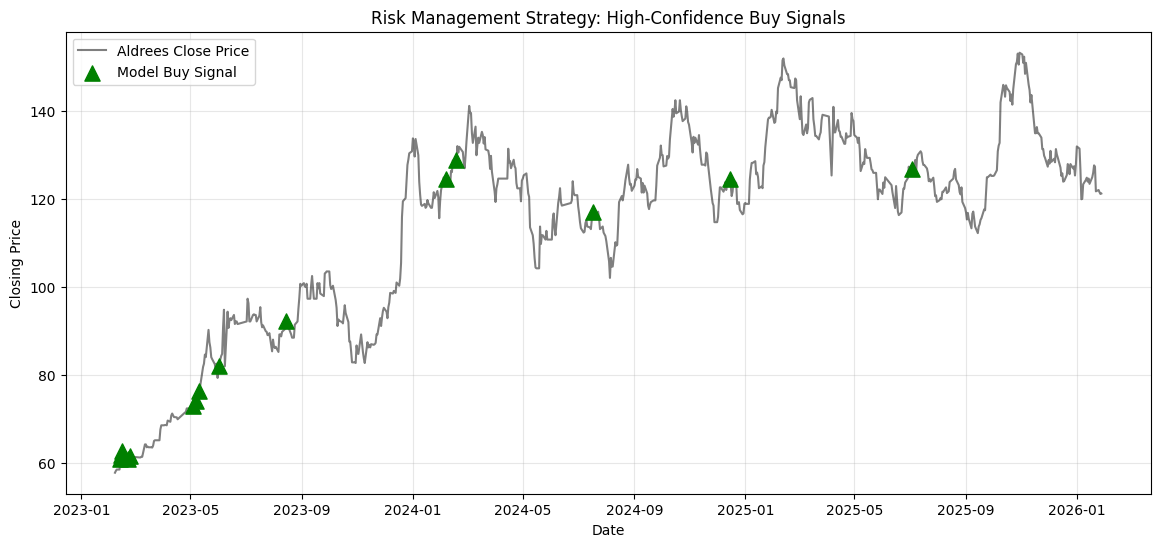

In [25]:
plt.figure(figsize=(14, 6))

# Plot the underlying stock price
plt.plot(X_test.index, X_test['Close'], label='Aldrees Close Price', color='black', alpha=0.5, linewidth=1.5)

# Find the exact dates and prices where our model predicted '1'
buy_signals = X_test[safe_predictions == 1]

# Overlay green triangles for Buy signals
plt.scatter(buy_signals.index, buy_signals['Close'], marker='^', color='green', s=120, label='Model Buy Signal', zorder=5)

plt.title('Risk Management Strategy: High-Confidence Buy Signals')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Final Conclusion & Next Steps

This project successfully transitioned from exploratory data analysis to building a highly conservative, risk-managed classification model. While we achieved a strong 71% precision rate on executed trades, this analysis highlights the limitations of purely technical trading. The massive post-2020 price surge was driven by macroeconomic factors (COVID-19 lockdowns, supply chain shifts, and regional geopolitics) that technical indicators simply cannot foresee.

**Next Steps:** To improve overall profitability and recall, future iterations of this model must incorporate exogenous variables, such as global Brent Crude oil prices, the Saudi TASI index performance, and NLP-driven sentiment analysis of daily financial news.